In [1]:
import importlib
import eval_functions
importlib.reload(eval_functions)
from eval_functions import *
import pandas as pd
from enum import Enum
import numpy as n

from IPython.display import display
# make tables interactive
from itables import init_notebook_mode
import itables.options as opt
init_notebook_mode(all_interactive=True, connected=True)
opt.maxBytes=0

In [2]:
KOFOLA_VERSION="4cc321b"
KOFOLA_TACAS23="kofola-tacas23-tacas23"
KOFOLA_SUBS_TUP="kofola-subs-tup-afb44c1"
OLD_KOFOLA="kofola-83ffdfc"
KOFOLA_BREAK="kofola-break-afb44c1"
KOFOLA_RED="kofola-red-d0fc1c7"
KOFOLA_TELA="kofola-tela-d0fc1c7"
KOFOLA_TELA_RED="kofola-tela-red-d0fc1c7"
SPOT="spot-2.14.1"
SPOT_RED="spot-red-2.14.1"
KOFOLA="kofola-"+KOFOLA_VERSION
KOFOLA_CHECK="kofola-check-"+KOFOLA_VERSION
KOFOLA_SUBS_TUP_CHECK="kofola-subs-tup-check-afb44c1"

# Timeout (in seconds) 
TIMEOUT=120


TOOLS = list(dict.fromkeys([ # small hack so that we get list of unique values (i.e. a set, but also in the given order; see https://stackoverflow.com/questions/1653970/does-python-have-an-ordered-set)
    KOFOLA,
    #OLD_KOFOLA,
    #KOFOLA_BREAK,
    #KOFOLA_RED,
    #KOFOLA_TELA,
    #KOFOLA_TELA_RED,
    SPOT,
    #SPOT_RED,
    #KOFOLA_TACAS23,
    #KOFOLA_SUBS_TUP,

    # you can add more tools here directly if needed
]))
TOOLS_CHECK = list(dict.fromkeys([
    KOFOLA_CHECK,
    #KOFOLA_SUBS_TUP_CHECK
]))

BENCHES = [
  "advanced_automata_termination",
  "autohyper",
  "pecan",
  "s1s",
  "state_of_buchi",
  "seminator",
  "ldba4ltl",
]

In [3]:
df_all = load_benches(BENCHES, TOOLS+TOOLS_CHECK, TIMEOUT) # last parameter is timeout
classification_df = parse_classifications_for_benchmarks(BENCHES)
# Join with main data
df_all = join_with_classification(df_all, classification_df)


## Evaluation

In [4]:

print(simple_table(df_all, TOOLS, BENCHES, separately=False))
print(simple_table(df_all, TOOLS, BENCHES, separately=True))

# of automata: 31273
----------------------------------------------------------------------------------------------------
tool               ✅    ❌      states    max-states    states-avg    states-med    time    time-avg    time-med    TO    ERR
--------------  -----  ----  ----------  ------------  ------------  ------------  ------  ----------  ----------  ----  -----
kofola-4cc321b  31271     2  2546355.00     394220.00         81.43          2.00  442.42        0.01        0.00     2      0
spot-2.14.1     31270     3  3606237.00     406339.00        115.33          2.00  190.67        0.01        0.00     2      1
----------------------------------------------------------------------------------------------------


Benchmark advanced_automata_termination
# of automata: 915
----------------------------------------------------------------------------------------------------
tool              ✅    ❌      states    max-states    states-avg    states-med    time    time-avg    time-me

In [5]:
TOOL_FOR_COMPARISON = KOFOLA

### States

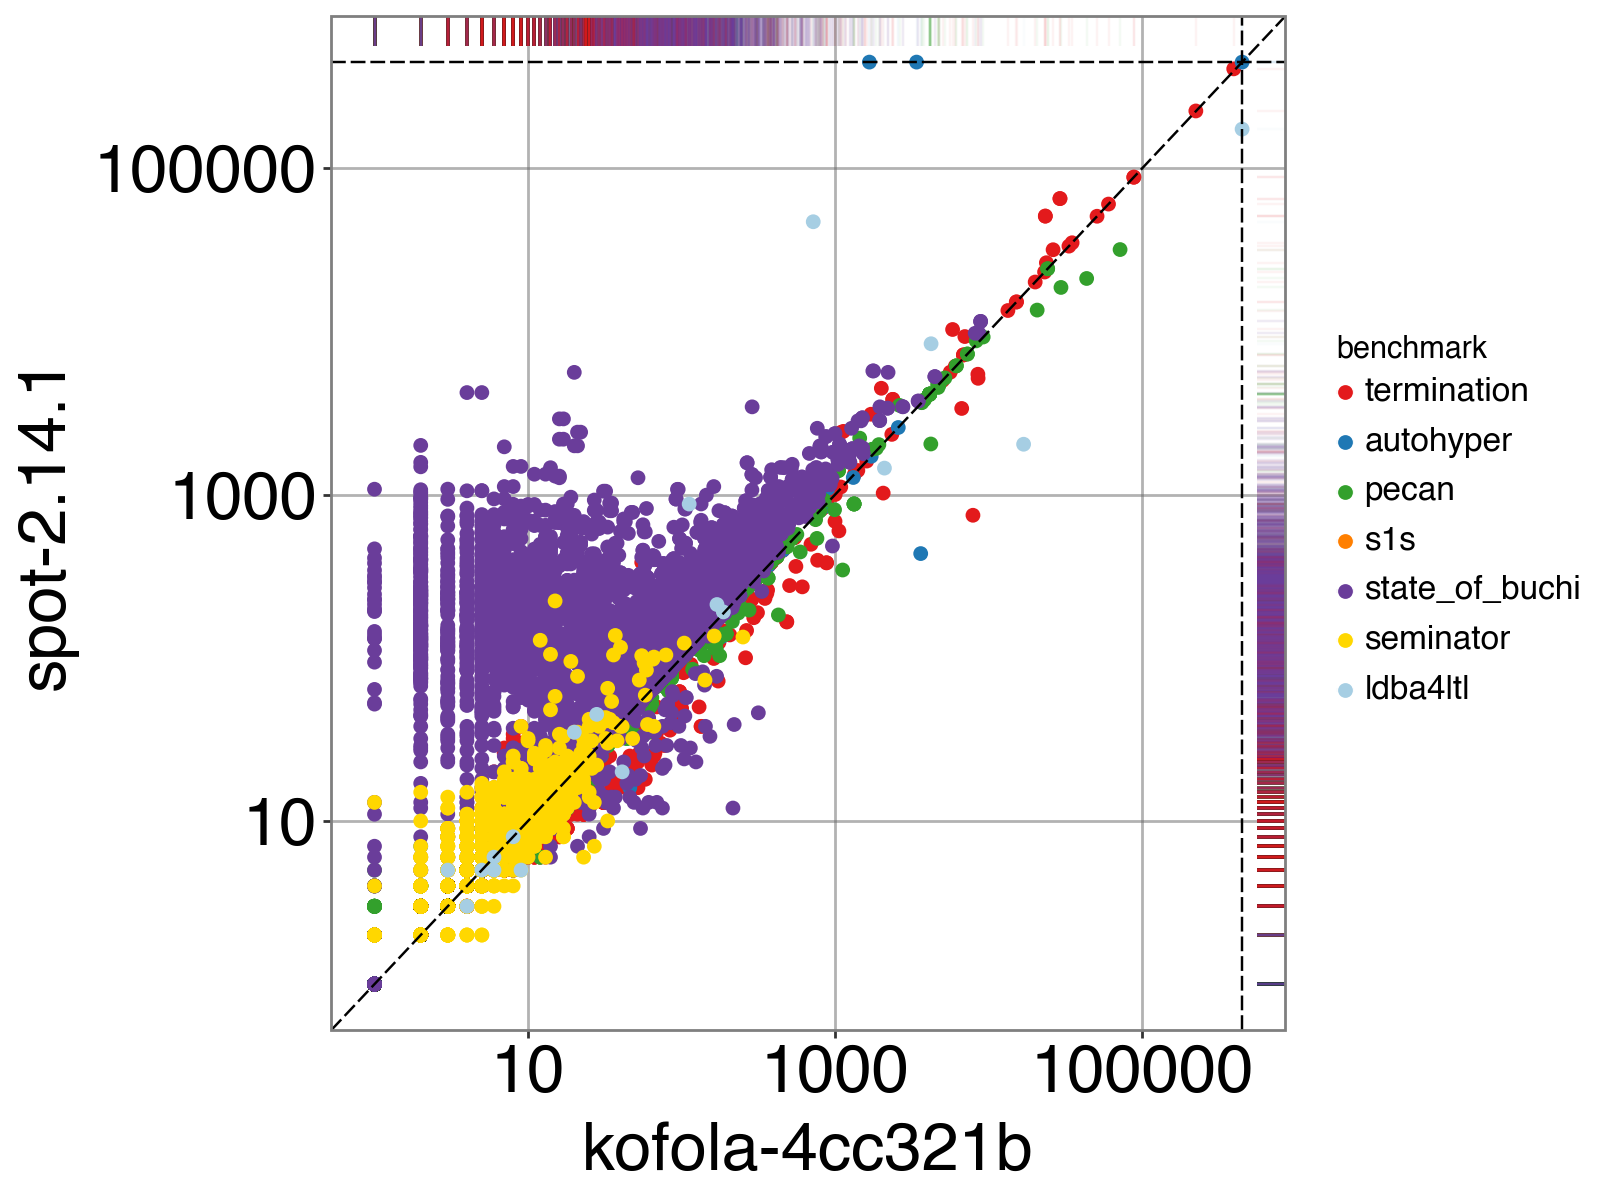

In [6]:
for tool in TOOLS:
    if tool != TOOL_FOR_COMPARISON:
        display(scatter_plot_states(df_all, TOOL_FOR_COMPARISON, tool, color_column="benchmark", clamp=False, legend_name_map={"advanced_automata_termination":"termination"}))

### Time

/Users/vhavlena/Documents/VeriFIT/Repo/Buchi complementation/ba-compl-eval/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


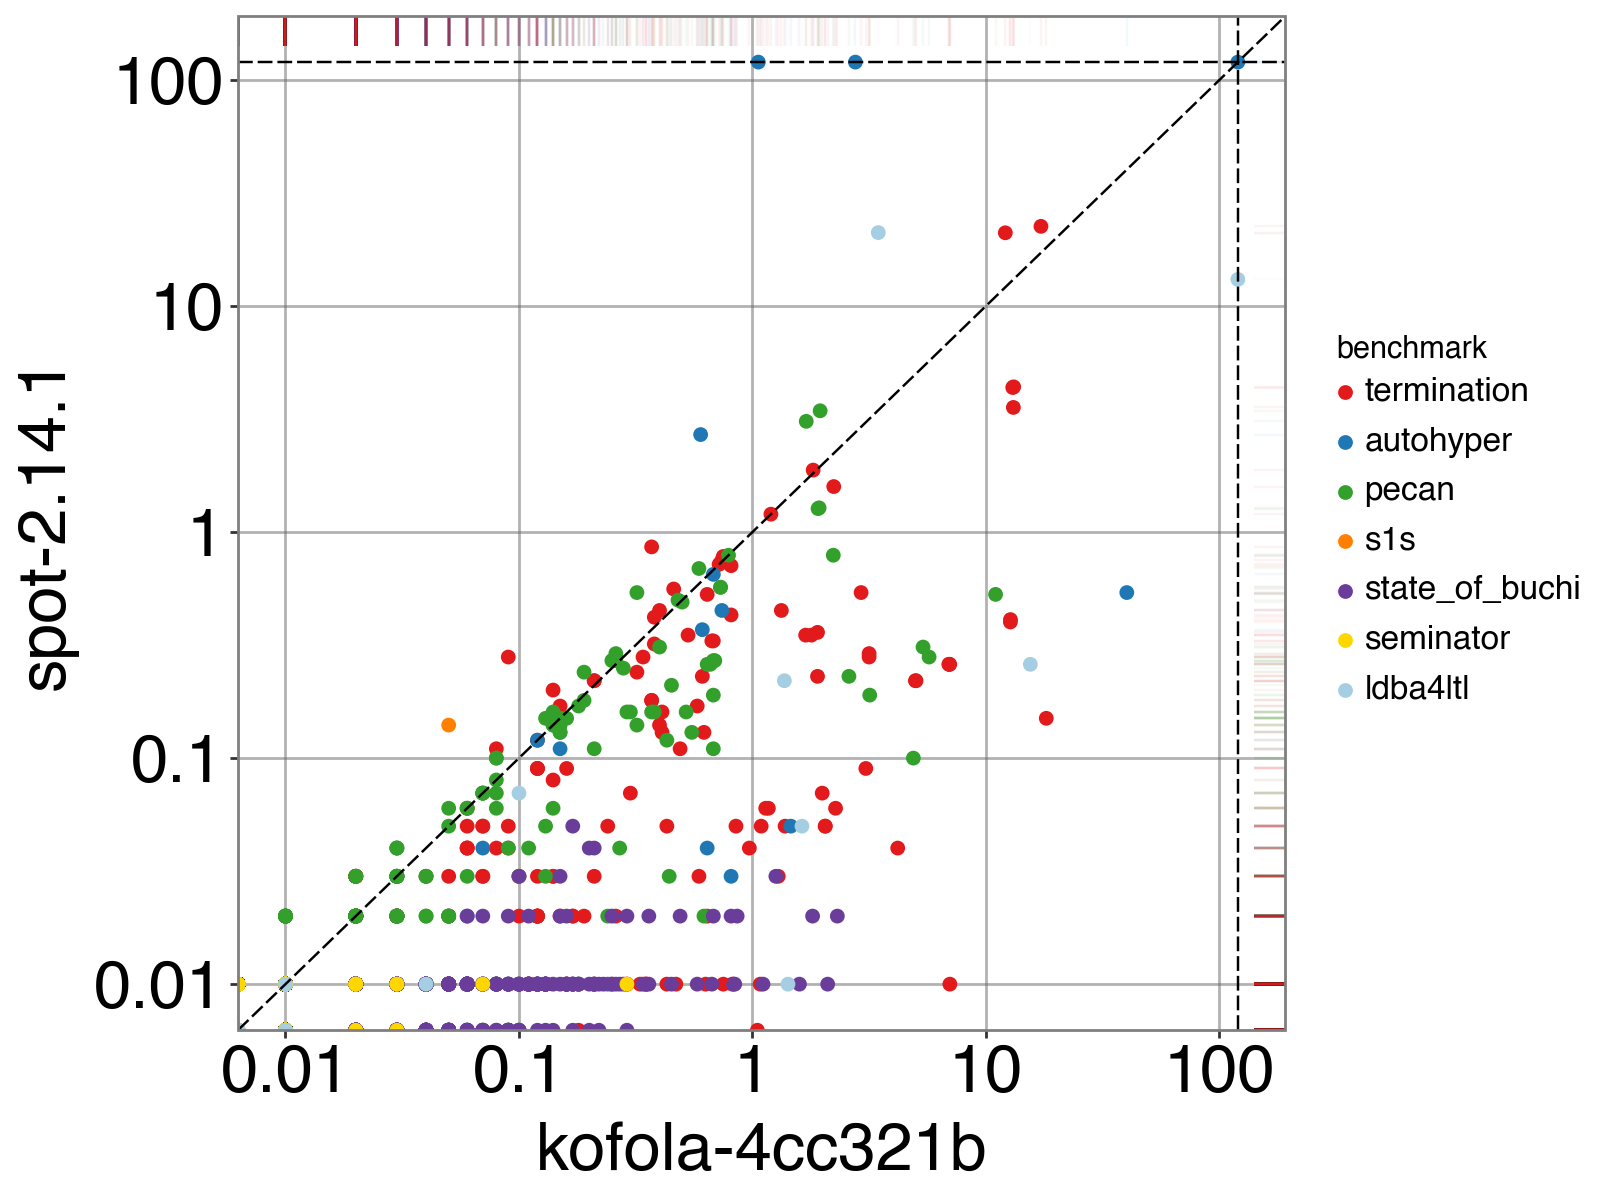

In [7]:
for tool in TOOLS:
    if tool != TOOL_FOR_COMPARISON:
        display(scatter_plot(df_all, TOOL_FOR_COMPARISON, tool, color_column="benchmark", timeout=TIMEOUT, legend_name_map={"advanced_automata_termination":"termination"}))

### More detailed evaluation

In [8]:
get_invalid(df_all, TOOLS_CHECK)

Loading ITables v2.4.4 from the internet... (need help?)


In [9]:
get_errors(df_all, TOOL_FOR_COMPARISON)

Loading ITables v2.4.4 from the internet... (need help?)


In [10]:
get_solved(df_all, TOOL_FOR_COMPARISON)

Loading ITables v2.4.4 from the internet... (need help?)


In [11]:
get_timeouts(df_all, TOOL_FOR_COMPARISON)

Loading ITables v2.4.4 from the internet... (need help?)
